# OVRO-LWA source metacatalog

Identify sources in OVRO-LWA wide-field FITS images with **PyBDSF**, then fuse
per-image catalogs into a **metacatalog** with one entry per unique sky position.

Pipeline (library: `lwa_catalog.create` + Parquet I/O):

1. **Discover** FITS under `FITS_ROOT` (LST hour + color band from filenames).
2. **Detect** sources per image (`iter_detect_sources`); workers write each `sources_*.parquet` as it finishes.
3. **LST merge** within each band (`merge_lst_metacatalog`) — one representative row per sky position (highest elevation among LST hours).
4. **Band merge** sequential Full→Blue→Green→Red (`build_global_metacatalog`) — astrometry and primary flux columns come from the seed row (`origin_band`), but **per-band flux is preserved** in `{field}_{band}` columns (`Peak_flux`, `Total_flux`, errors, and LST `Peak_flux_std` for each color band).

Catalogs are written as **Parquet** under `OUTPUT_DIR` via `CatalogLayout`.
Set `REUSE_CACHED_CATALOGS = True` to skip PyBDSF / LST merge when caches exist.
Set `MIGRATE_LEGACY_CSV = True` once to convert old CSV/FITS catalog trees.

After changing `BAND_FIELDS` / flux columns, rebuild the metacatalog (set `REUSE_CACHED_CATALOGS = False` for the fusion cell or delete `metacatalog.parquet`).


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from lwa_catalog import CatalogLayout, migrate_output_dir
from lwa_catalog.create import (
    build_global_metacatalog,
    discover_fits_files,
    discovered_slots,
    iter_detect_sources,
    lst_hours_from_discovery,
    merge_lst_metacatalog,
)
from lwa_catalog.io import (
    lst_merged_cache_complete,
    read_all_lst_merged,
    read_sources_catalog,
    sources_cache_complete,
    write_lst_merged,
    write_metacatalog,
)

# --- user configuration ---------------------------------------------------
#FITS_ROOT = Path("/fast/claw")  # directory containing FITS images (searched recursively)
FITS_ROOT = Path("/lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827")
# Glob(s) relative to FITS_ROOT (rglob). Default: all .fits. Examples:
#   "I_*_deep_Taper_R0_*.fits"  or  ("*.fits", "*_LST*h_*.fits")
#FITS_GLOB: str | tuple[str, ...] = "*.fits"
#FITS_GLOB = "??h_[RGBF]*//*_I_deep_Taper_Robust+0.0_dewarped*fits" 
FITS_GLOB = "??h_[RGBF]*/*_I_deep_Taper_Robust-0.75*pbcorr*fits"
OUTPUT_DIR = Path("/fast/claw/metacatalog_coaddR-0.75")  # Parquet catalog tree

# Upsample images before PyBDSF (finer pixel grid; WCS CDELT/CRPIX updated in detect)
BDSF_UPSAMPLE_FACTOR = 2

# PyBDSF detection parameters (ncores=1; parallelize across images instead)
BDSF_KW = dict(
    thresh="hard",
    thresh_isl=3.0,
    thresh_pix=4.0,
    atrous_do=False,
    psf_vary_do=False,
    quiet=True,
    ncores=1,
)

# Worker processes for iter_detect_sources (one PyBDSF run per image)
DETECT_N_JOBS = 10

# Optional subset of LST hour bins (e.g. ["01h", "02h"]). None = all discovered.
LST_HOURS_OVERRIDE: list[str] | None = None
ASSOC_BANDS = ("Blue", "Green", "Red")

# When True, skip PyBDSF / LST merge if matching Parquet files already exist
REUSE_CACHED_CATALOGS = True

# One-time CSV/FITS → Parquet migration (no-op if only Parquet is present)
MIGRATE_LEGACY_CSV = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
layout = CatalogLayout(OUTPUT_DIR)

if MIGRATE_LEGACY_CSV:
    migrated = migrate_output_dir(layout)
    print(f"Migrated {len(migrated)} legacy catalog file(s) under {OUTPUT_DIR}")


## Filename parsing

Discover FITS under `FITS_ROOT` and parse LST hour / color band from filenames
(`lwa_catalog.create.discover`). Band names are defined as notebook constants below.


In [2]:
# Explicit catalog constants (notebook-local; passed into library APIs below)
COLOR_BANDS = ("Full", "Blue", "Green", "Red")


In [3]:
_fits_patterns = (FITS_GLOB,) if isinstance(FITS_GLOB, str) else tuple(FITS_GLOB)
fits_files = discover_fits_files(FITS_ROOT, patterns=_fits_patterns)
_discovered_lst_hours = lst_hours_from_discovery(fits_files)
LST_HOURS = list(LST_HOURS_OVERRIDE) if LST_HOURS_OVERRIDE is not None else _discovered_lst_hours
fits_by_slot = discovered_slots(fits_files)
summary = pd.DataFrame(
    {
        "path": [m.path.name for m in fits_files],
        "lst_hour": [m.lst_hour for m in fits_files],
        "band": [m.band for m in fits_files],
        "time_key": [m.time_key for m in fits_files],
    }
)
print(f"Found {len(fits_files)} FITS files under {FITS_ROOT} matching {list(_fits_patterns)}")
print(
    f"LST hours from discovery ({len(_discovered_lst_hours)}): "
    f"{', '.join(_discovered_lst_hours)}"
)
if LST_HOURS_OVERRIDE is not None:
    print(f"LST hours in use (override): {', '.join(LST_HOURS)}")
else:
    print(f"LST hours in use (all discovered): {', '.join(LST_HOURS)}")
summary.sort_values(["lst_hour", "band"]).reset_index(drop=True)


Found 92 FITS files under /lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827 matching ['??h_[RGBF]*/*_I_deep_Taper_Robust-0.75*pbcorr*fits']
LST hours from discovery (23): 00h, 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h
LST hours in use (all discovered): 00h, 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h


,path,lst_hour,band,time_key
0,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,00h,Blue,None
1,Full_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,00h,Full,None
2,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,00h,Green,None
3,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,00h,Red,None
4,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,01h,Blue,None
...,...,...,...,...
87,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,21h,Red,None
88,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,22h,Blue,None
89,Full_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,22h,Full,None
90,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,22h,Green,None


## PyBDSF source detection

Detect sources per image with PyBDSF (`lwa_catalog.create.detect`).
Images are upsampled by `BDSF_UPSAMPLE_FACTOR` (default 2×) before detection.
`GAUL_COLUMNS` and `BDSF_KW` are notebook-local; cache helpers wrap Parquet I/O.


In [4]:
GAUL_COLUMNS = [
    "RA",
    "DEC",
    "S_Code",
    "Total_flux",
    "E_Total_flux",
    "Peak_flux",
    "E_Peak_flux",
    "Maj",
    "Min",
    "PA",
    "DC_Maj",
    "DC_Min",
    "DC_PA",
    "Resid_Isl_rms",
    "Resid_Isl_mean",
]


def all_sources_cached() -> bool:
    """True when every discovered (lst, band) slot has a sources Parquet file."""
    return sources_cache_complete(layout, sorted(fits_by_slot))


def all_lst_merged_cached() -> bool:
    """True when every color band has an LST-merged Parquet file."""
    return lst_merged_cache_complete(layout, COLOR_BANDS)


def load_sources_catalog(lst_hour: str, band: str) -> pd.DataFrame:
    """Load a per-image sources Parquet catalog, backfilling beam from the FITS image."""
    meta = fits_by_slot[(lst_hour, band)]
    return read_sources_catalog(layout, lst_hour, band, fits_path=meta.path)


def load_per_image_catalogs_from_disk() -> dict[tuple[str, str], pd.DataFrame]:
    """Load all per-image catalogs from OUTPUT_DIR when every slot is cached."""
    catalogs: dict[tuple[str, str], pd.DataFrame] = {}
    for lst_hour, band in sorted(fits_by_slot):
        catalogs[(lst_hour, band)] = load_sources_catalog(lst_hour, band)
    return catalogs


def load_lst_merged_from_disk() -> dict[str, pd.DataFrame]:
    """Load LST-merged per-band catalogs from OUTPUT_DIR."""
    return read_all_lst_merged(layout, COLOR_BANDS)


In [5]:
per_image_catalogs: dict[tuple[str, str], pd.DataFrame] = {}
todo = []

for (lst_hour, band), meta in sorted(fits_by_slot.items()):
    key = (lst_hour, band)
    out_path = layout.sources(lst_hour, band)

    if REUSE_CACHED_CATALOGS and out_path.is_file():
        catalog = load_sources_catalog(lst_hour, band)
        per_image_catalogs[key] = catalog
        print(f"Cached {key}: {len(catalog)} sources <- {out_path.name}")
        continue

    todo.append((key, meta))

if todo:
    todo_metas = [meta for _, meta in todo]
    todo_paths = [layout.sources(meta.lst_hour, meta.band) for meta in todo_metas]
    for meta, out_path, n_sources in iter_detect_sources(
        todo_metas,
        todo_paths,
        n_jobs=DETECT_N_JOBS,
        bdsf_kw=BDSF_KW,
        gaul_columns=GAUL_COLUMNS,
        upsample_factor=BDSF_UPSAMPLE_FACTOR,
    ):
        key = (meta.lst_hour, meta.band)
        per_image_catalogs[key] = load_sources_catalog(meta.lst_hour, meta.band)
        print(f"Detected {key}: {n_sources} sources -> {out_path.name}")


Cached ('00h', 'Blue'): 30580 sources <- sources_00h_Blue.parquet
Cached ('00h', 'Full'): 17268 sources <- sources_00h_Full.parquet
Cached ('00h', 'Green'): 19417 sources <- sources_00h_Green.parquet
Cached ('00h', 'Red'): 7814 sources <- sources_00h_Red.parquet
Cached ('01h', 'Blue'): 35653 sources <- sources_01h_Blue.parquet
Cached ('01h', 'Full'): 21284 sources <- sources_01h_Full.parquet
Cached ('01h', 'Green'): 22075 sources <- sources_01h_Green.parquet
Cached ('01h', 'Red'): 8587 sources <- sources_01h_Red.parquet
Cached ('02h', 'Blue'): 37778 sources <- sources_02h_Blue.parquet
Cached ('02h', 'Full'): 21265 sources <- sources_02h_Full.parquet
Cached ('02h', 'Green'): 22492 sources <- sources_02h_Green.parquet
Cached ('02h', 'Red'): 8783 sources <- sources_02h_Red.parquet
Cached ('03h', 'Blue'): 37458 sources <- sources_03h_Blue.parquet
Cached ('03h', 'Full'): 21517 sources <- sources_03h_Full.parquet
Cached ('03h', 'Green'): 22930 sources <- sources_03h_Green.parquet
Cached ('03

## Metacatalog fusion

**LST merge** (within each band): cluster detections across LST hours and keep one
representative row per sky position (`merge_lst_metacatalog`; highest elevation).

**Band merge** (Full→Blue→Green→Red): cross-match LST-merged catalogs and fuse into
one row per sky position (`build_global_metacatalog`). Primary `RA`/`DEC`/`Peak_flux`/
`Total_flux` come from the seed band (`origin_band`). Associated bands contribute
**per-band columns** from `BAND_FLUX_FIELDS` in `lwa_catalog.constants` — e.g.
`Peak_flux_Blue`, `E_Peak_flux_Green`, `Peak_flux_std_Red` — so flux is not collapsed
to a single value when multiple color bands match. Spectral indices use
`Total_flux_{band}` and `E_Total_flux_{band}`.


In [6]:
from lwa_catalog.constants import BAND_FIELDS, BAND_FLUX_FIELDS

# LST merge collapses to one representative row; band merge copies flux per band.
assert BAND_FLUX_FIELDS == (
    "Peak_flux",
    "Total_flux",
    "E_Peak_flux",
    "E_Total_flux",
    "Peak_flux_std",
)
for col in BAND_FLUX_FIELDS:
    assert col in BAND_FIELDS


def per_band_flux_columns(bands: tuple[str, ...] = COLOR_BANDS) -> list[str]:
    """Metacatalog column names for per-band flux preservation."""
    cols: list[str] = []
    for band in bands:
        for field in BAND_FLUX_FIELDS:
            cols.append(f"{field}_{band}")
    return cols


In [7]:
lst_merged: dict[str, pd.DataFrame] = {}

if REUSE_CACHED_CATALOGS and all_lst_merged_cached():
    lst_merged = load_lst_merged_from_disk()
    for band in COLOR_BANDS:
        print(
            f"LST merge ({band}): loaded {len(lst_merged[band])} sources from "
            f"{layout.lst_merged(band).name}"
        )
else:
    if not per_image_catalogs and REUSE_CACHED_CATALOGS and all_sources_cached():
        per_image_catalogs.update(load_per_image_catalogs_from_disk())
        print(f"Loaded {len(per_image_catalogs)} per-image catalogs from {OUTPUT_DIR}")

    for band in COLOR_BANDS:
        band_catalogs = [
            per_image_catalogs[(lst, band)]
            for lst in LST_HOURS
            if (lst, band) in per_image_catalogs
        ]
        merged = merge_lst_metacatalog(band_catalogs, band=band)
        lst_merged[band] = merged
        out_path = write_lst_merged(merged, layout, band)
        print(f"LST merge ({band}): {len(merged)} sources -> {out_path}")

metacatalog = build_global_metacatalog(
    lst_merged,
    assoc_bands=ASSOC_BANDS,
    band_fields=BAND_FIELDS,
    color_bands=COLOR_BANDS,
)
meta_path = write_metacatalog(metacatalog, layout)

if per_image_catalogs:
    n_inputs = sum(len(df) for df in per_image_catalogs.values())
    input_desc = f"{n_inputs} per-image detections"
else:
    n_inputs = sum(int(df["n_lst_contributions"].sum()) for df in lst_merged.values())
    input_desc = f"{n_inputs} LST-merged rows (cached)"
print(f"\nGlobal metacatalog: {len(metacatalog)} sources from {input_desc}")
print(f"Wrote {meta_path}")
print(
    f"Per-band flux columns ({len(per_band_flux_columns())}): "
    f"{', '.join(per_band_flux_columns()[:4])}, ..."
)
metacatalog.head(10)


LST merge (Full): 52928 sources -> /fast/claw/metacatalog_coaddR-0.75/metacatalog_lst_Full.parquet
LST merge (Blue): 105136 sources -> /fast/claw/metacatalog_coaddR-0.75/metacatalog_lst_Blue.parquet
LST merge (Green): 58546 sources -> /fast/claw/metacatalog_coaddR-0.75/metacatalog_lst_Green.parquet
LST merge (Red): 23667 sources -> /fast/claw/metacatalog_coaddR-0.75/metacatalog_lst_Red.parquet

Global metacatalog: 106426 sources from 1789212 per-image detections
Wrote /fast/claw/metacatalog_coaddR-0.75/metacatalog.parquet


,meta_id,origin_band,bands_present,RA,DEC,Peak_flux,Total_flux,Maj,Min,PA,...,Resid_Isl_mean,E_Peak_flux,E_Total_flux,source_file_Blue,source_file_Green,source_file_Red,alpha_RG,E_alpha_RG,alpha_GB,E_alpha_GB
0,52928,Blue,"Blue,Green,Red",139.531658,-12.083057,323.170494,273.734210,0.183495,0.070159,1.886712,...,-0.335073,0.220597,0.362957,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,5.131983,0.091760,-1.181901,0.007281
1,104584,Green,Green,260.128812,-1.009566,192.001238,259.017323,0.223315,0.152792,10.856220,...,-0.300298,0.605669,1.291377,NaN,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,NaN,NaN,NaN,NaN,NaN
2,0,Full,"Full,Blue,Green",50.957352,-37.270010,134.308337,470.834005,0.832059,0.320809,1.545318,...,-0.628781,0.583109,2.568004,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,NaN,NaN,NaN,4.028440,0.061367
3,1,Full,Full,83.202484,21.689783,115.627967,10.334795,0.236481,0.046696,153.209398,...,2.379366,0.106558,0.287275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,Full,"Full,Green,Red",64.580073,38.045189,102.037185,118.043944,0.161627,0.141639,53.457789,...,-0.212045,0.254008,0.486559,NaN,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,1.608324,0.121685,NaN,NaN
5,106103,Red,Red,94.331922,22.791127,82.614939,175.712877,0.340906,0.282653,111.998455,...,-0.028168,0.923767,2.742207,NaN,NaN,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,NaN,NaN,NaN,NaN
6,106104,Red,Red,264.967213,-29.484241,78.481357,286.016034,1.602926,0.559456,22.055783,...,12.395028,1.720043,7.821773,NaN,NaN,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,NaN,NaN,NaN,NaN
7,3,Full,"Full,Blue,Green,Red",283.880459,1.421455,77.884035,229.653956,0.359245,0.205638,9.714796,...,-0.201717,1.351496,5.186160,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,-0.394445,0.124168,-1.083184,0.068027
8,4,Full,"Full,Blue,Green,Red",278.237177,-10.180164,75.701683,197.839401,0.297432,0.268480,172.452063,...,7.186057,2.002988,6.977083,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,0.734800,0.306761,-3.528618,0.133311
9,106105,Red,Red,263.720777,-29.388074,73.860762,1248.728693,5.610481,0.704167,21.399878,...,12.395028,0.986625,17.658279,NaN,NaN,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,NaN,NaN,NaN,NaN


In [8]:
# LST merge yield (Full band)
full_lst = lst_merged["Full"]
multi_lst = full_lst[full_lst["n_lst_contributions"] > 1].sort_values("n_lst_contributions", ascending=False)
print(f"Full-band sources after LST merge: {len(full_lst)}")
print(f"  seen in multiple LST hours: {len(multi_lst)}")
if len(multi_lst):
    display(multi_lst.head(10)[["RA", "DEC", "Peak_flux", "n_lst_contributions", "lst_hours", "representative_lst"]])

# Global band merge
print(f"\nGlobal rows by origin_band:")
print(metacatalog["origin_band"].value_counts())

full_with_color = metacatalog[
    (metacatalog["origin_band"] == "Full")
    & (metacatalog[[f"n_assoc_{b}" for b in ASSOC_BANDS]].max(axis=1) > 0)
]
print(f"Full-seeded rows with at least one color-band association: {len(full_with_color)}")

summary_cols = [
    "meta_id",
    "RA",
    "DEC",
    "origin_band",
    "bands_present",
    "Peak_flux",
    "Total_flux",
    "E_Peak_flux",
    "E_Total_flux",
    "Peak_flux_std",
    *[f"n_assoc_{b}" for b in ASSOC_BANDS],
]
summary_cols = [c for c in summary_cols if c in metacatalog.columns]
display(metacatalog.head(10)[summary_cols])

flux_cols = ["meta_id", "origin_band", "bands_present", *per_band_flux_columns()]
flux_cols = [c for c in flux_cols if c in metacatalog.columns]
print(f"\nPer-band flux columns ({len(flux_cols) - 3} flux fields × {len(COLOR_BANDS)} bands):")
display(metacatalog.head(10)[flux_cols])

Full-band sources after LST merge: 52928
  seen in multiple LST hours: 46675


,RA,DEC,Peak_flux,n_lst_contributions,lst_hours,representative_lst
25,252.747777,5.022867,38.472855,261,"12h,13h,14h,15h,16h,17h,18h,19h,20h,21h",17h
45,350.937585,58.720011,33.127468,246,"00h,01h,02h,03h,04h,05h,06h,07h,08h,14h,15h,16...",00h
518,123.367980,48.210459,13.723513,235,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",08h
121,69.111561,29.687558,22.753045,229,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,22h",05h
7,6.417295,64.111163,63.197013,227,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",00h
394,83.543693,22.081642,15.479653,221,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h",06h
1252,49.724124,41.865641,9.687296,213,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,20...",03h
1444,139.446288,-12.265417,9.124884,202,"05h,06h,07h,08h,09h,10h,11h,12h,13h",09h
1734,280.399369,79.913913,8.461118,192,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",19h
990,34.430228,86.358707,10.626127,186,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",02h



Global rows by origin_band:
origin_band
Full     52928
Blue     51656
Green     1519
Red        323
Name: count, dtype: int64
Full-seeded rows with at least one color-band association: 52213


,meta_id,RA,DEC,origin_band,Peak_flux,lst_hours,n_assoc_Blue,n_assoc_Green,n_assoc_Red
0,52928,139.531658,-12.083057,Blue,323.170494,"05h,06h,07h,08h,09h,10h,11h,12h,13h",1,1,1
1,104584,260.128812,-1.009566,Green,192.001238,"13h,14h,15h,16h,17h,18h,19h,20h,21h",0,1,0
2,0,50.957352,-37.270010,Full,134.308337,"02h,03h,04h",1,1,0
3,1,83.202484,21.689783,Full,115.627967,11h,0,0,0
4,2,64.580073,38.045189,Full,102.037185,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,21...",0,1,1
5,106103,94.331922,22.791127,Red,82.614939,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11h",0,0,1
6,106104,264.967213,-29.484241,Red,78.481357,15h,0,0,1
7,3,283.880459,1.421455,Full,77.884035,"14h,15h,16h,17h,18h,19h,20h,21h,22h",1,1,1
8,4,278.237177,-10.180164,Full,75.701683,"14h,15h,16h,17h,18h,19h,20h,21h,22h",1,1,1
9,106105,263.720777,-29.388074,Red,73.860762,15h,0,0,1


## Fit quality

Summarize detection fit quality on **`lst_merged`** (representative-row residuals and fluxes).
Requires the fusion cells above so `lst_merged` is populated.

Three categories:

1. **Island residual stats** — flag the top 1% of `Resid_Isl_rms` and the top 1% of
   `|Resid_Isl_mean|` within each band (union = high-residual set).
2. **Unphysical flux ratio** — allow `Total_flux < Peak_flux` within error; flag only when
   `(Total_flux - Peak_flux) / hypot(E_Total_flux, E_Peak_flux) < -3`.
   Rows missing either error are not flagged.
3. **Source density** — 1°×1° RA–Dec histogram; report densest bins and overlay flagged
   sources on a Full-band map. Flat RA–Dec bins exaggerate area near the NCP.

This section is read-only QA (does not rewrite Parquet catalogs).


In [9]:
import numpy as np

FLUX_UNPHYSICAL_NSIGMA = 3.0
RESIDUAL_PERCENTILE = 99.0  # top 1%
DENSITY_BIN_DEG = 3.0
FIT_QA_DISPLAY_ROWS = 15

_RESID_COLS = ("Resid_Isl_rms", "Resid_Isl_mean")
_FLUX_COLS = ("Total_flux", "Peak_flux", "E_Total_flux", "E_Peak_flux")
_POS_COLS = ("RA", "DEC")


def _missing_columns(df: pd.DataFrame, cols: tuple[str, ...]) -> list[str]:
    return [c for c in cols if c not in df.columns]


def flux_sigma_total_minus_peak(df: pd.DataFrame) -> pd.Series:
    """Return (Total - Peak) / hypot(E_Total, E_Peak); non-finite where inputs invalid."""
    missing = _missing_columns(df, _FLUX_COLS)
    if missing:
        return pd.Series(np.nan, index=df.index, dtype=float)
    total = df["Total_flux"].to_numpy(dtype=float)
    peak = df["Peak_flux"].to_numpy(dtype=float)
    e_tot = df["E_Total_flux"].to_numpy(dtype=float)
    e_peak = df["E_Peak_flux"].to_numpy(dtype=float)
    denom = np.hypot(e_tot, e_peak)
    sigma = np.full(len(df), np.nan, dtype=float)
    ok = (
        np.isfinite(total)
        & np.isfinite(peak)
        & np.isfinite(e_tot)
        & np.isfinite(e_peak)
        & (denom > 0)
    )
    sigma[ok] = (total[ok] - peak[ok]) / denom[ok]
    return pd.Series(sigma, index=df.index, name="flux_sigma_T_minus_P")


def flag_unphysical_flux(
    df: pd.DataFrame, *, nsigma: float = FLUX_UNPHYSICAL_NSIGMA
) -> pd.Series:
    """True where Total is significantly below Peak (sigma < -nsigma). Missing errors → False."""
    sigma = flux_sigma_total_minus_peak(df)
    return (sigma < -float(nsigma)).fillna(False).rename("unphysical_flux")


def flag_residual_top_percentile(
    df: pd.DataFrame, *, percentile: float = RESIDUAL_PERCENTILE
) -> pd.DataFrame:
    """Boolean columns: high_resid_rms, high_resid_abs_mean, high_residual (union)."""
    out = pd.DataFrame(index=df.index)
    missing = _missing_columns(df, _RESID_COLS)
    if missing:
        out["high_resid_rms"] = False
        out["high_resid_abs_mean"] = False
        out["high_residual"] = False
        return out

    rms = df["Resid_Isl_rms"].to_numpy(dtype=float)
    mean = df["Resid_Isl_mean"].to_numpy(dtype=float)
    abs_mean = np.abs(mean)

    high_rms = np.zeros(len(df), dtype=bool)
    high_abs = np.zeros(len(df), dtype=bool)

    finite_rms = np.isfinite(rms)
    if finite_rms.any():
        thr_rms = np.nanpercentile(rms[finite_rms], percentile)
        high_rms = finite_rms & (rms >= thr_rms)

    finite_abs = np.isfinite(abs_mean)
    if finite_abs.any():
        thr_abs = np.nanpercentile(abs_mean[finite_abs], percentile)
        high_abs = finite_abs & (abs_mean >= thr_abs)

    out["high_resid_rms"] = high_rms
    out["high_resid_abs_mean"] = high_abs
    out["high_residual"] = high_rms | high_abs
    return out


def sky_density_histogram(
    df: pd.DataFrame, *, bin_deg: float = DENSITY_BIN_DEG
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (H, ra_edges, dec_edges) for finite RA/DEC with fixed bin width in degrees."""
    missing = _missing_columns(df, _POS_COLS)
    if missing:
        return np.zeros((0, 0)), np.array([]), np.array([])
    ra = df["RA"].to_numpy(dtype=float)
    dec = df["DEC"].to_numpy(dtype=float)
    ok = np.isfinite(ra) & np.isfinite(dec)
    if not ok.any():
        return np.zeros((0, 0)), np.array([]), np.array([])
    ra = ra[ok]
    dec = dec[ok]
    bin_deg = float(bin_deg)
    ra_min, ra_max = np.floor(ra.min() / bin_deg) * bin_deg, np.ceil(ra.max() / bin_deg) * bin_deg
    dec_min, dec_max = np.floor(dec.min() / bin_deg) * bin_deg, np.ceil(dec.max() / bin_deg) * bin_deg
    if ra_max <= ra_min:
        ra_max = ra_min + bin_deg
    if dec_max <= dec_min:
        dec_max = dec_min + bin_deg
    n_ra = max(1, int(np.round((ra_max - ra_min) / bin_deg)))
    n_dec = max(1, int(np.round((dec_max - dec_min) / bin_deg)))
    ra_edges = ra_min + np.arange(n_ra + 1) * bin_deg
    dec_edges = dec_min + np.arange(n_dec + 1) * bin_deg
    H, _, _ = np.histogram2d(ra, dec, bins=[ra_edges, dec_edges])
    return H, ra_edges, dec_edges


def densest_bins(
    H: np.ndarray,
    ra_edges: np.ndarray,
    dec_edges: np.ndarray,
    *,
    n: int = 10,
) -> pd.DataFrame:
    """Return the densest histogram bins (count, bin centers)."""
    if H.size == 0:
        return pd.DataFrame(columns=["count", "RA_center", "DEC_center", "i_ra", "i_dec"])
    flat = H.ravel()
    order = np.argsort(flat)[::-1]
    rows = []
    for idx in order[: max(0, int(n))]:
        if flat[idx] <= 0:
            break
        i_ra, i_dec = np.unravel_index(int(idx), H.shape)
        rows.append(
            {
                "count": int(flat[idx]),
                "RA_center": float(0.5 * (ra_edges[i_ra] + ra_edges[i_ra + 1])),
                "DEC_center": float(0.5 * (dec_edges[i_dec] + dec_edges[i_dec + 1])),
                "i_ra": int(i_ra),
                "i_dec": int(i_dec),
            }
        )
    return pd.DataFrame(rows)


print(
    f"Fit-quality helpers ready "
    f"(residual p{RESIDUAL_PERCENTILE:g}, unphysical {FLUX_UNPHYSICAL_NSIGMA:g}σ, "
    f"density {DENSITY_BIN_DEG:g}°)."
)


Fit-quality helpers ready (residual p99, unphysical 3σ, density 3°).


In [10]:
# Per-band residual + unphysical flux summaries (stores fit_qa for density overlay)
fit_qa: dict[str, dict] = {}

for band in COLOR_BANDS:
    df = lst_merged[band]
    print(f"\n=== {band}: {len(df)} LST-merged sources ===")
    entry: dict = {
        "n_sources": int(len(df)),
        "high_residual": pd.Series(False, index=df.index),
        "unphysical_flux": pd.Series(False, index=df.index),
        "flux_sigma": pd.Series(np.nan, index=df.index),
        "skipped_residual": False,
        "skipped_flux": False,
    }

    miss_resid = _missing_columns(df, _RESID_COLS)
    if miss_resid:
        print(f"  SKIP residual QA — missing columns: {miss_resid}")
        entry["skipped_residual"] = True
        entry["n_resid_top1"] = 0
    else:
        flags = flag_residual_top_percentile(df, percentile=RESIDUAL_PERCENTILE)
        entry["high_residual"] = flags["high_residual"]
        entry["n_resid_top1"] = int(flags["high_residual"].sum())
        n_rms = int(flags["high_resid_rms"].sum())
        n_abs = int(flags["high_resid_abs_mean"].sum())
        n_finite_rms = int(np.isfinite(df["Resid_Isl_rms"].to_numpy(dtype=float)).sum())
        print(
            f"  Residual top-1%: union={entry['n_resid_top1']} "
            f"(rms={n_rms}, |mean|={n_abs}; finite Resid_Isl_rms={n_finite_rms})"
        )
        show_cols = [c for c in ["RA", "DEC", "Peak_flux", "Resid_Isl_rms", "Resid_Isl_mean", "S_Code"] if c in df.columns]
        outliers = (
            df.loc[flags["high_residual"], show_cols]
            .assign(_sort=df.loc[flags["high_residual"], "Resid_Isl_rms"])
            .sort_values("_sort", ascending=False)
            .drop(columns="_sort")
            .head(FIT_QA_DISPLAY_ROWS)
        )
        if len(outliers):
            display(outliers)
        else:
            print("  (no residual outliers)")

    miss_flux = _missing_columns(df, _FLUX_COLS)
    if miss_flux:
        print(f"  SKIP unphysical-flux QA — missing columns: {miss_flux}")
        entry["skipped_flux"] = True
        entry["n_unphysical_3sig"] = 0
    else:
        sigma = flux_sigma_total_minus_peak(df)
        unphys = flag_unphysical_flux(df, nsigma=FLUX_UNPHYSICAL_NSIGMA)
        entry["flux_sigma"] = sigma
        entry["unphysical_flux"] = unphys
        entry["n_unphysical_3sig"] = int(unphys.sum())
        print(f"  Unphysical flux (σ < -{FLUX_UNPHYSICAL_NSIGMA:g}): {entry['n_unphysical_3sig']}")
        show_cols = [c for c in ["RA", "DEC", "Total_flux", "Peak_flux", "E_Total_flux", "E_Peak_flux"] if c in df.columns]
        bad = df.loc[unphys, show_cols].copy()
        bad.insert(0, "flux_sigma_T_minus_P", sigma.loc[unphys])
        bad = bad.sort_values("flux_sigma_T_minus_P").head(FIT_QA_DISPLAY_ROWS)
        if len(bad):
            display(bad)
        else:
            print("  (no unphysical-flux sources)")

    fit_qa[band] = entry

print("\nStored per-band flags in fit_qa.")



=== Full: 52928 LST-merged sources ===
  Residual top-1%: union=762 (rms=530, |mean|=531; finite Resid_Isl_rms=52928)


,RA,DEC,Peak_flux,Resid_Isl_rms,Resid_Isl_mean
3085,344.635930,58.683672,6.716752,42.280674,-2.742633
438,352.134673,58.939779,14.666191,42.280674,-2.742633
42,201.737827,-39.972004,33.708330,19.304707,17.692804
1002,201.157643,-40.344285,10.601612,19.304707,17.692804
5716,350.436769,59.397545,5.092001,13.043088,6.860993
30,270.618410,-22.872193,37.813278,9.820296,9.366805
434,266.531014,-30.786510,14.811359,9.361041,9.024036
160,260.444401,-35.808272,20.770284,9.361041,9.024036
212,267.329226,-29.468201,19.212990,9.361041,9.024036
71,264.609275,-30.613066,28.024862,7.822670,11.056253


  Unphysical flux (σ < -3): 85


,flux_sigma_T_minus_P,RA,DEC,Total_flux,Peak_flux,E_Total_flux,E_Peak_flux
3883,-3283.250127,24.396998,33.201806,0.013129,6.088446,0.000977,0.001572
52142,-1545.533292,0.129518,43.951942,0.000674,0.921085,0.000223,0.000552
2401,-732.717580,213.436237,51.846842,0.049589,7.450882,0.001188,0.010031
1,-343.645653,83.202484,21.689783,10.334795,115.627967,0.287275,0.106558
24,-335.244705,187.277512,2.107758,2.187491,38.846148,0.104634,0.031764
25,-167.176021,252.747777,5.022867,3.845999,38.472855,0.195858,0.067391
783,-96.088266,9.580130,-2.114953,0.861938,11.702452,0.104067,0.043566
38656,-81.838795,69.696373,29.968547,0.001729,1.517691,0.018456,0.001587
1734,-77.628021,280.399369,79.913913,0.554454,8.461118,0.091113,0.045525
45,-72.744058,350.937585,58.720011,10.703988,33.127468,0.205153,0.230069



=== Blue: 105136 LST-merged sources ===
  Residual top-1%: union=1539 (rms=1053, |mean|=1052; finite Resid_Isl_rms=105136)


...


=== Red: 23667 LST-merged sources ===
  Residual top-1%: union=309 (rms=237, |mean|=237; finite Resid_Isl_rms=23667)


,RA,DEC,Peak_flux,Resid_Isl_rms,Resid_Isl_mean
5140,51.897063,-36.939947,8.728527,269.336365,-196.236313
3889,348.995618,59.332322,10.064079,126.060806,-42.540646
825,351.553205,59.813793,22.085096,126.060806,-42.540646
500,353.567786,60.092092,28.231344,55.561138,19.095394
2220,352.665996,60.234314,13.456507,55.561138,19.095394
215,345.757581,58.485146,41.150465,55.561138,19.095394
871,352.096948,60.041998,21.476288,55.561138,19.095394
997,352.334001,60.658541,20.229505,55.561138,19.095394
22,349.776171,59.542269,103.581156,55.561138,19.095394
20207,141.029540,-9.394588,3.426446,37.113285,14.659576


  Unphysical flux (σ < -3): 36


,flux_sigma_T_minus_P,RA,DEC,Total_flux,Peak_flux,E_Total_flux,E_Peak_flux
1770,-38589.051118,139.926221,-11.512967,0.001255,15.087600,0.000142,0.000364
11,-292.165375,49.908255,41.508485,21.742699,144.157838,0.381576,0.173074
1,-273.677682,252.800940,4.871280,27.539792,213.863380,0.616654,0.288522
32,-231.093301,64.550390,38.076775,9.538365,92.438266,0.339492,0.115896
141,-201.711461,96.787433,-5.861213,3.046274,48.527444,0.184771,0.129226
22,-152.863403,349.776171,59.542269,14.763432,103.581156,0.315657,0.487804
3,-98.233853,50.635646,-36.477421,66.708606,192.702366,1.245809,0.304953
509,-65.141279,341.369339,39.749925,3.923475,27.870337,0.337704,0.145244
1350,-51.975723,122.178222,-10.392351,1.550444,17.387320,0.243079,0.183720
1023,-44.385370,123.875046,-3.035329,2.246294,19.986657,0.372849,0.143996



Stored per-band flags in fit_qa.


Densest 3° bins (Full):


,count,RA_center,DEC_center,i_ra,i_dec
0,36,163.5,19.5,54,20
1,32,187.5,10.5,62,17
2,31,85.5,22.5,28,21
3,30,34.5,19.5,11,20
4,30,82.5,22.5,27,21
5,29,58.5,22.5,19,21
6,29,112.5,16.5,37,19
7,29,73.5,13.5,24,18
8,28,139.5,-13.5,46,9
9,28,124.5,7.5,41,16


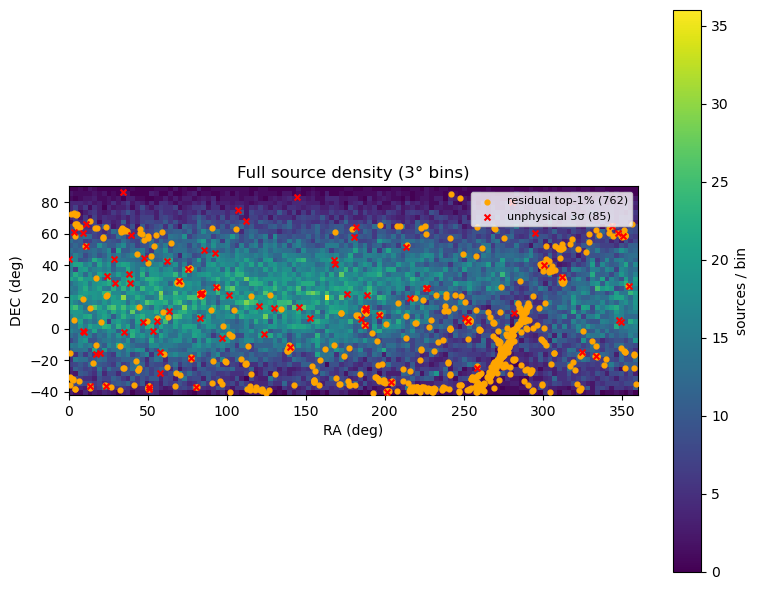


Fit-quality roll-up:


,band,n_sources,n_resid_top1,n_unphysical_3sig,max_bin_count,n_resid_and_unphysical
0,Full,52928,762,85,36,22
1,Blue,105136,1539,327,87,83
2,Green,58546,819,69,38,25
3,Red,23667,309,36,20,16


In [11]:
import matplotlib.pyplot as plt

# Full-band 1° density map + flagged overlays; roll-up for all bands
primary_band = "Full" if "Full" in lst_merged else COLOR_BANDS[0]
df_full = lst_merged[primary_band]
H, ra_edges, dec_edges = sky_density_histogram(df_full, bin_deg=DENSITY_BIN_DEG)
top_bins = densest_bins(H, ra_edges, dec_edges, n=10)
print(f"Densest {DENSITY_BIN_DEG:g}° bins ({primary_band}):")
display(top_bins)

if H.size:
    fig, ax = plt.subplots(figsize=(8, 6))
    # H is (n_ra, n_dec); pcolormesh expects X,Y as edges
    mesh = ax.pcolormesh(ra_edges, dec_edges, H.T, shading="auto", cmap="viridis")
    fig.colorbar(mesh, ax=ax, label="sources / bin")
    qa = fit_qa.get(primary_band, {})
    high = qa.get("high_residual", pd.Series(False, index=df_full.index))
    unphys = qa.get("unphysical_flux", pd.Series(False, index=df_full.index))
    if high.any():
        ax.scatter(
            df_full.loc[high, "RA"],
            df_full.loc[high, "DEC"],
            s=12,
            c="orange",
            marker="o",
            label=f"residual top-1% ({int(high.sum())})",
            zorder=3,
        )
    if unphys.any():
        ax.scatter(
            df_full.loc[unphys, "RA"],
            df_full.loc[unphys, "DEC"],
            s=18,
            c="red",
            marker="x",
            label=f"unphysical 3σ ({int(unphys.sum())})",
            zorder=4,
        )
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("DEC (deg)")
    ax.set_title(f"{primary_band} source density ({DENSITY_BIN_DEG:g}° bins)")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    print(f"No finite RA/DEC for density map ({primary_band}).")

# Roll-up summary across bands
rows = []
for band in COLOR_BANDS:
    df = lst_merged[band]
    qa = fit_qa.get(band, {})
    H_b, _, _ = sky_density_histogram(df, bin_deg=DENSITY_BIN_DEG)
    max_bin = int(H_b.max()) if H_b.size else 0
    high = qa.get("high_residual", pd.Series(False, index=df.index))
    unphys = qa.get("unphysical_flux", pd.Series(False, index=df.index))
    rows.append(
        {
            "band": band,
            "n_sources": int(len(df)),
            "n_resid_top1": int(qa.get("n_resid_top1", high.sum())),
            "n_unphysical_3sig": int(qa.get("n_unphysical_3sig", unphys.sum())),
            "max_bin_count": max_bin,
            "n_resid_and_unphysical": int((high & unphys).sum()),
        }
    )

fit_qa_summary = pd.DataFrame(rows)
print("\nFit-quality roll-up:")
display(fit_qa_summary)


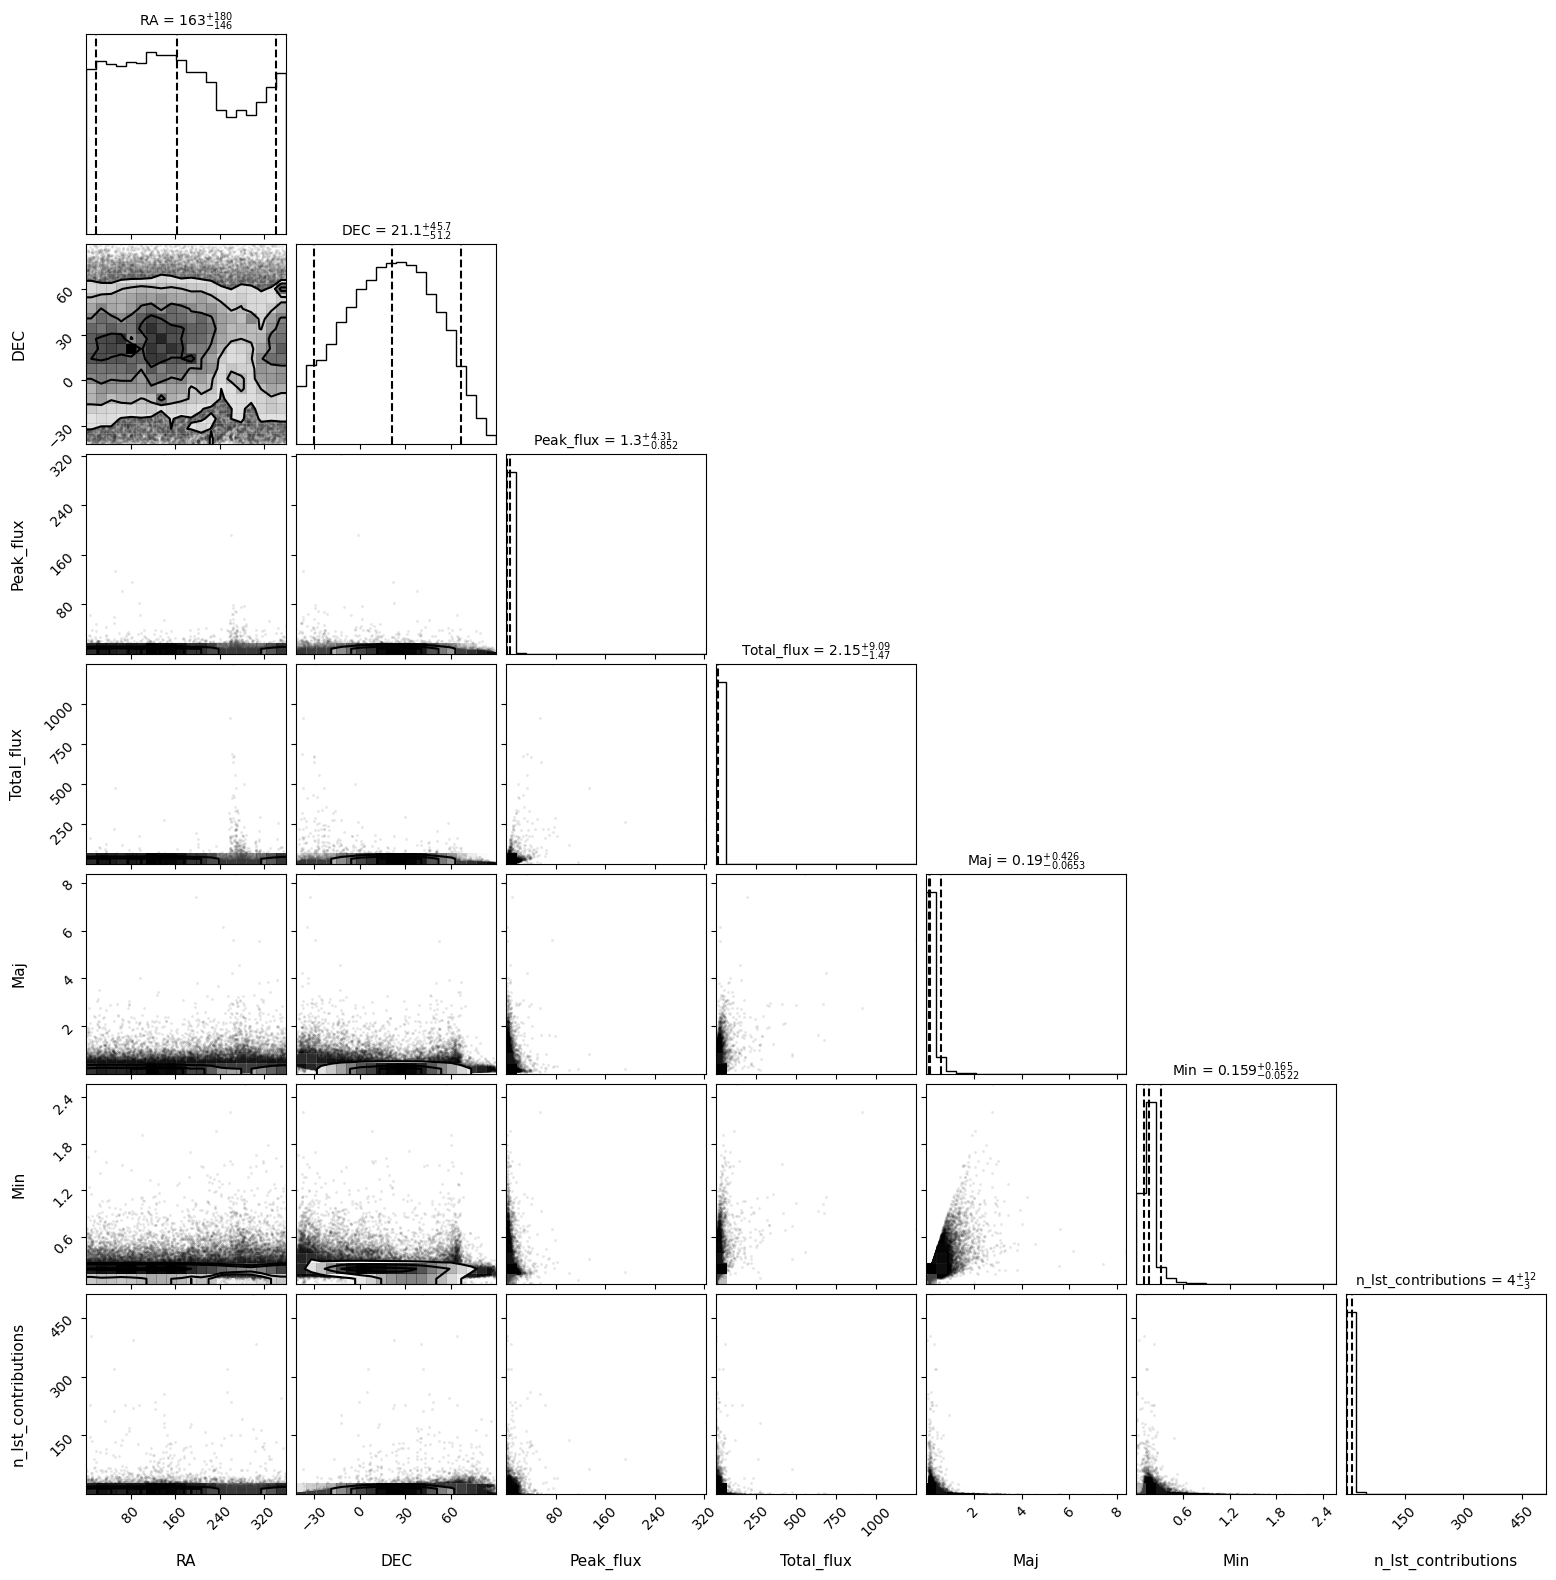

In [12]:
import corner
import matplotlib.pyplot as plt

cols = ["RA", "DEC", "Peak_flux", "Total_flux", "Maj", "Min", "n_lst_contributions"]

# drop NaNs; corner needs a clean numeric array
data = metacatalog[cols].dropna().to_numpy()

fig = corner.corner(
    data,
    labels=cols,
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 11},
)

# Save before show — Cursor/VS Code often cannot "download" inline plot images.
#OUT_PNG = OUTPUT_DIR / "metacatalog_corner.png"
#fig.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
#print(f"Wrote {OUT_PNG}")
plt.show()


## Spectral index distribution

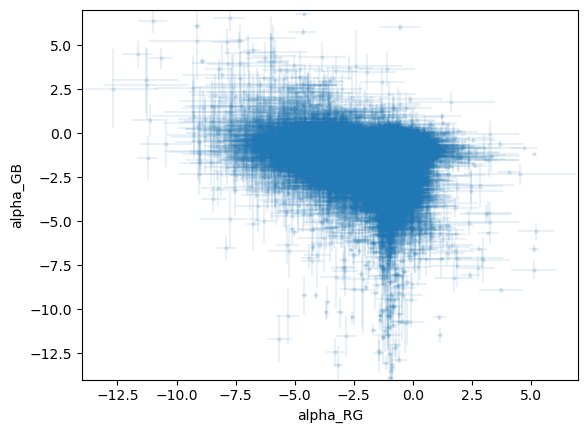

In [13]:
cols = ['meta_id', 'alpha_RG', 'E_alpha_RG', 'alpha_GB', 'E_alpha_GB']
data = metacatalog[cols].dropna(how='any')
ax = data.plot(x='alpha_RG', y='alpha_GB', xerr='E_alpha_RG', yerr='E_alpha_GB', marker='.', kind='scatter',
               alpha=0.1, xlim=[-14,7], ylim=[-14,7])
OUT_PNG = OUTPUT_DIR / "metacatalog_alpha.png"
ax.figure.savefig(OUT_PNG, dpi=150, bbox_inches="tight")

In [14]:
meta_ids = data[(data['alpha_RG']>1) & (data['alpha_GB']<-2)]['meta_id']

In [15]:
metacatalog.set_index('meta_id').loc[meta_ids].reset_index()

,meta_id,origin_band,bands_present,RA,DEC,Peak_flux,Total_flux,Maj,Min,PA,...,Resid_Isl_mean,E_Peak_flux,E_Total_flux,source_file_Blue,source_file_Green,source_file_Red,alpha_RG,E_alpha_RG,alpha_GB,E_alpha_GB
0,23,Full,"Full,Blue,Green,Red",123.852398,-3.134624,38.968607,36.829632,0.162404,0.156874,45.015609,...,0.299829,0.321350,0.536816,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,7.518548,0.415025,-4.695778,0.067480
1,28,Full,"Full,Blue,Green,Red",103.784713,54.162107,38.025306,39.751387,0.151457,0.136325,45.830851,...,-0.076990,0.258283,0.461442,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,3.724419,0.924357,-8.885261,0.084867
2,35,Full,"Full,Blue,Green,Red",75.730833,25.278389,36.163951,38.172622,0.144698,0.136089,42.986930,...,-0.176298,0.235283,0.423008,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,3.208301,0.449513,-5.670490,0.082648
3,44,Full,"Full,Blue,Green,Red",341.437486,39.699667,33.222053,49.410594,0.199193,0.148946,116.549240,...,-0.041432,0.295080,0.677228,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,5.134057,0.225680,-6.581774,0.227665
4,78,Full,"Full,Blue,Green,Red",354.102355,21.163056,27.010804,51.332732,0.209011,0.195949,121.226162,...,-0.002063,0.344484,0.937903,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,2.434519,0.434480,-8.039811,0.193737
5,191,Full,"Full,Blue,Green,Red",9.016663,58.939654,19.936028,41.142219,0.239133,0.193383,20.400703,...,0.627277,0.383498,1.111692,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,2.789221,0.360472,-6.562498,0.145460
6,219,Full,"Full,Blue,Green,Red",333.662189,13.825214,18.967055,45.745029,0.231661,0.226193,84.892055,...,0.461392,0.308815,1.007822,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,1.150773,0.102256,-11.474865,0.429734
7,446,Full,"Full,Blue,Green,Red",200.308654,11.115711,14.548219,21.158956,0.184928,0.172929,44.035142,...,0.775315,0.287065,0.643873,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,8.653230,0.874245,-8.571757,0.672677
8,937,Full,"Full,Blue,Green,Red",192.905751,8.955763,10.886132,12.975418,0.172744,0.157161,22.369575,...,-0.168631,0.331063,0.646389,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,8.626690,0.630576,-4.937885,0.355131
9,1572,Full,"Full,Blue,Green,Red",105.711652,44.529030,8.808703,9.049716,0.146510,0.133207,52.281849,...,-0.065448,0.247078,0.436271,Blue_I_deep_Taper_Robust-0.75_pbcorr_dewarped_...,Green_I_deep_Taper_Robust-0.75_pbcorr_dewarped...,Red_I_deep_Taper_Robust-0.75_pbcorr_dewarped_a...,1.019694,0.565040,-2.354331,0.150202


In [23]:
metacatalog.columns

Index(['meta_id', 'origin_band', 'bands_present', 'RA', 'DEC', 'Peak_flux',
       'Total_flux', 'Maj', 'Min', 'PA', 'DC_Maj', 'DC_Min', 'DC_PA',
       'BMAJ_match', 'n_lst_contributions', 'lst_hours', 'representative_lst',
       'Peak_flux_std', 'Peak_flux_Blue', 'Total_flux_Blue',
       'E_Total_flux_Blue', 'RA_Blue', 'DEC_Blue', 'Maj_Blue', 'Min_Blue',
       'PA_Blue', 'DC_Maj_Blue', 'DC_Min_Blue', 'DC_PA_Blue', 'n_assoc_Blue',
       'Peak_flux_Green', 'Total_flux_Green', 'E_Total_flux_Green', 'RA_Green',
       'DEC_Green', 'Maj_Green', 'Min_Green', 'PA_Green', 'DC_Maj_Green',
       'DC_Min_Green', 'DC_PA_Green', 'n_assoc_Green', 'Peak_flux_Red',
       'Total_flux_Red', 'E_Total_flux_Red', 'RA_Red', 'DEC_Red', 'Maj_Red',
       'Min_Red', 'PA_Red', 'DC_Maj_Red', 'DC_Min_Red', 'DC_PA_Red',
       'n_assoc_Red', 'BMAJ_full', 'source_file_Full', 'Peak_flux_Full',
       'Total_flux_Full', 'E_Total_flux_Full', 'RA_Full', 'DEC_Full',
       'Maj_Full', 'Min_Full', 'PA_Full', 'DC_

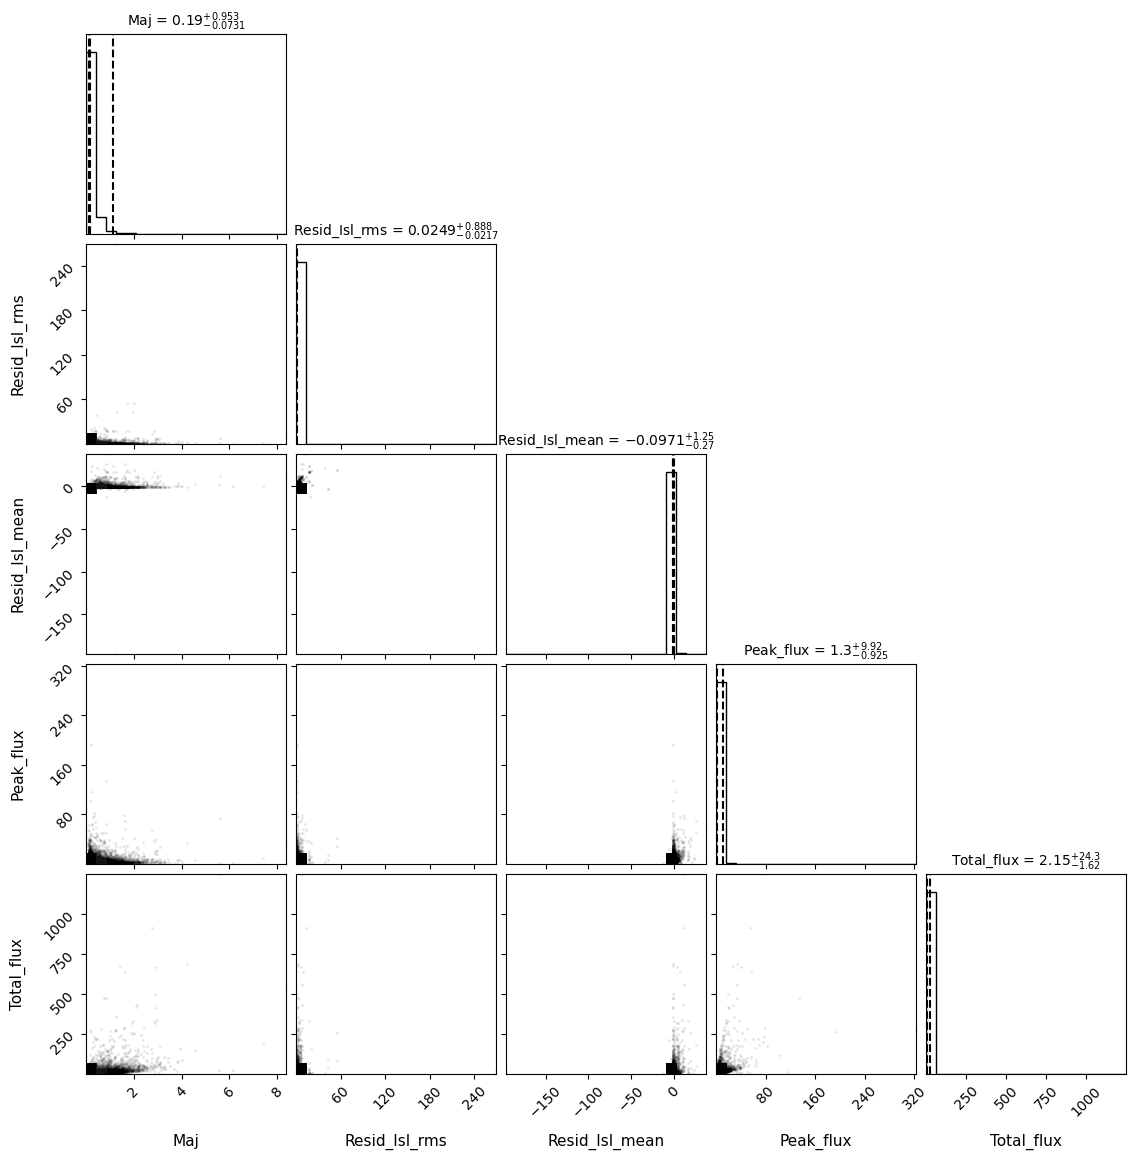

In [39]:
import corner
import matplotlib.pyplot as plt

cols = ["Maj", "Resid_Isl_rms", "Resid_Isl_mean", "Peak_flux", "Total_flux"]

# drop NaNs; corner needs a clean numeric array
data = metacatalog[cols].dropna().to_numpy()

fig = corner.corner(
    data,
    labels=cols,
    quantiles=[0.01, 0.5, 0.99],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 11},
)

# Save before show — Cursor/VS Code often cannot "download" inline plot images.
#OUT_PNG = OUTPUT_DIR / "metacatalog_corner.png"
#fig.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
#print(f"Wrote {OUT_PNG}")
plt.show()


In [40]:
np.quantile(data[:,1], [0.01, 0.5, 0.99])

array([0.00318304, 0.02491864, 0.91284136])